In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

master = pd.read_csv('../data/cleaned/master_table.csv')
sns.set_style('whitegrid')
print(master.shape)

(119143, 27)


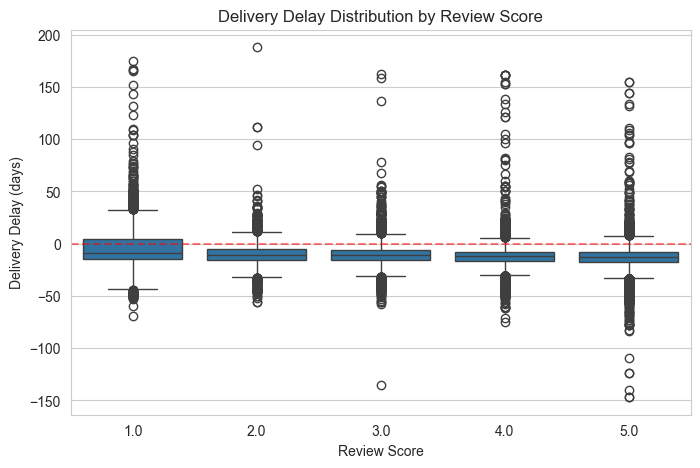

In [2]:
plt.figure(figsize=(8,5))
sns.boxplot(data=master, x='review_score', y='delivery_delay_days')
plt.title('Delivery Delay Distribution by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Delivery Delay (days)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.savefig('../reports/chart1_delay_vs_review.png', dpi=150, bbox_inches='tight')
plt.show()

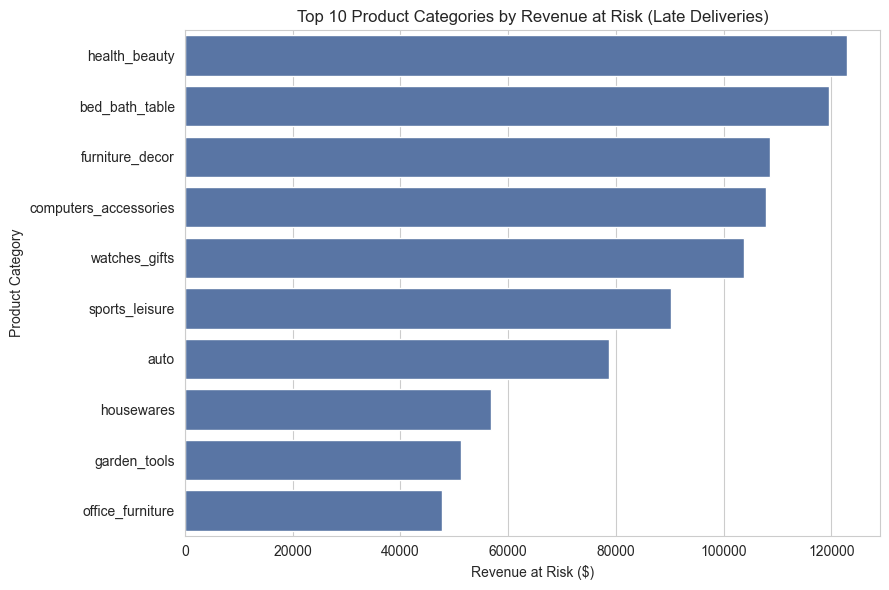

In [3]:
import sqlite3

conn = sqlite3.connect('../data/cleaned/olist.db')

query3_final = """
SELECT
  product_category_name_english,
  SUM(payment_value) AS revenue_at_risk,
  COUNT(DISTINCT order_id) AS num_orders
FROM master_table
WHERE delivery_delay_days > 0
GROUP BY product_category_name_english
HAVING COUNT(DISTINCT order_id) > 20
ORDER BY revenue_at_risk DESC
LIMIT 10;
"""

top_categories = pd.read_sql(query3_final, conn)

plt.figure(figsize=(9,6))
sns.barplot(data=top_categories, y='product_category_name_english', x='revenue_at_risk', color='#4C72B0')
plt.title('Top 10 Product Categories by Revenue at Risk (Late Deliveries)')
plt.xlabel('Revenue at Risk ($)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.savefig('../reports/chart2_top_categories_risk.png', dpi=150, bbox_inches='tight')
plt.show()

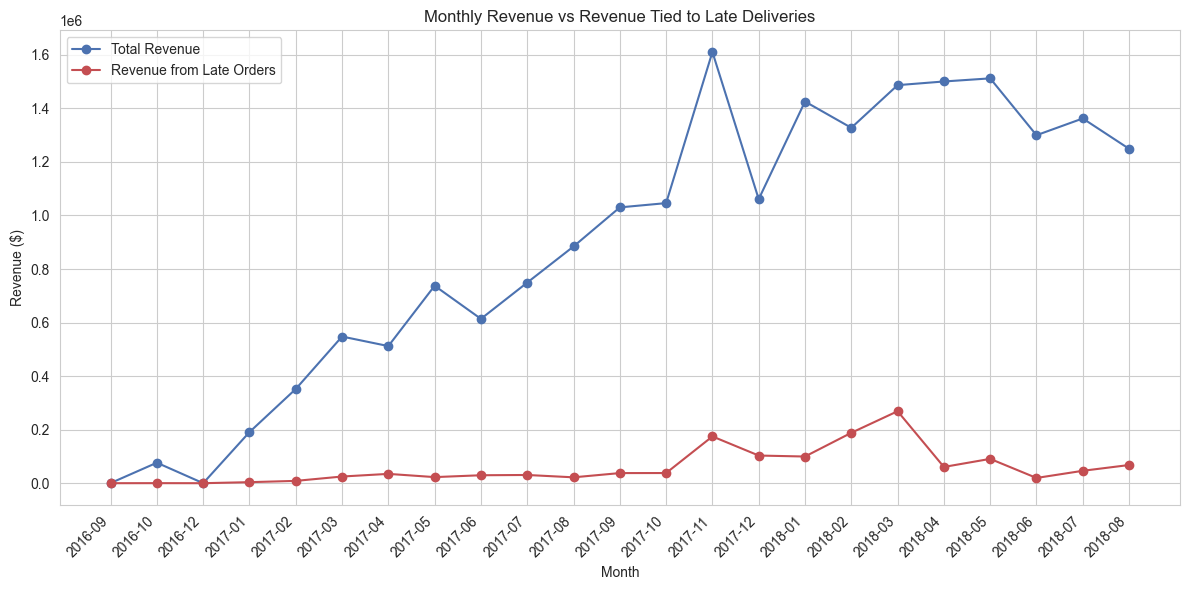

In [4]:
query4 = """
SELECT
  strftime('%Y-%m', order_purchase_timestamp) AS month,
  SUM(payment_value) AS total_revenue,
  SUM(CASE WHEN delivery_delay_days > 0 THEN payment_value ELSE 0 END) AS revenue_from_late_orders
FROM master_table
GROUP BY month
ORDER BY month;
"""

trend = pd.read_sql(query4, conn)

# Drop the incomplete last two months (Sept/Oct 2018) so the chart doesn't misleadingly show a "crash"
trend = trend[~trend['month'].isin(['2018-09', '2018-10'])]

plt.figure(figsize=(12,6))
plt.plot(trend['month'], trend['total_revenue'], marker='o', label='Total Revenue', color='#4C72B0')
plt.plot(trend['month'], trend['revenue_from_late_orders'], marker='o', label='Revenue from Late Orders', color='#C44E52')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Revenue vs Revenue Tied to Late Deliveries')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/chart3_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
conn.close()